7/16 from Antoine.

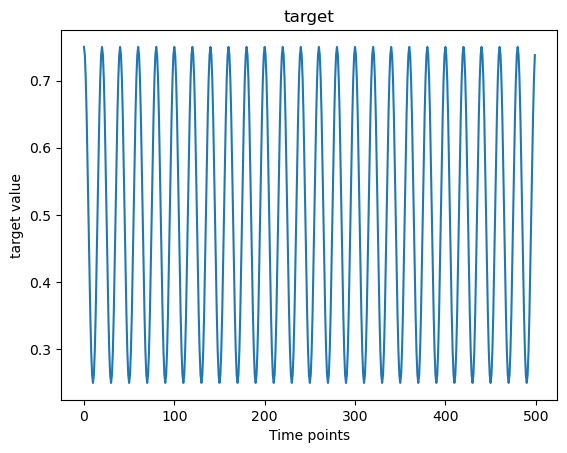

"\n# define targets\ntime_points = np.arange(5000)\nhalf_period = 10\n\n# Defining Inputs and Targets\ndef generate_MackeyGlass(ntimes, tau):\n    # initial condition\n    # x_values = np.random.uniform(0,1,tau).tolist()\n    x_values = [0.1]*tau\n\n    def mackey_glass(x, tau, gamma=0.1, beta0=0.2, n=10):\n        dxdt = beta0 * x[-tau] / (1 + x[-tau]**n) - gamma * x[-1]\n        return dxdt\n\n    x_t = x_values[-1]\n    for t in range(ntimes):\n        dxdt = mackey_glass(x_values, tau)\n        x_t = x_t + dxdt\n        x_values.append(x_t)\n\n    x = x_values[tau:]\n    return x\n\ntotal_time_steps = 5000\ntau = 20\nMG_sequence = np.array(generate_MackeyGlass(total_time_steps, tau))\n\n# fonction objectif à reproduire \ntargets = MG_sequence\n# Mise à l'échelle des targets pour être dans l'intervalle (0, 1) (pour éviter des problèmes avec le logarithme plus tard)\ntargets_scaled = (targets - np.min(targets)) / (np.max(targets) - np.min(targets))\ntargets_scaled = np.clip(targets_s

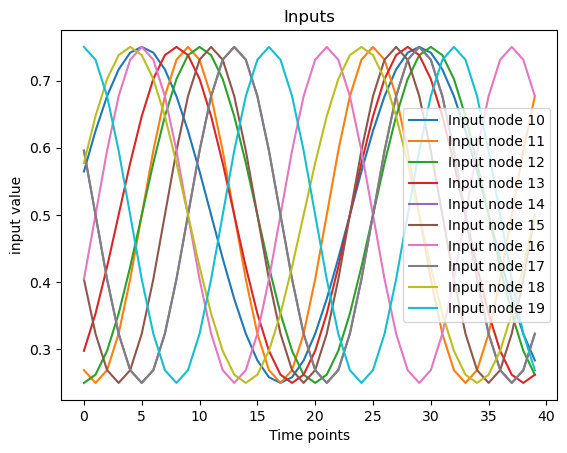

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import tensor
from torch import nn
import seaborn as sns
from torch.autograd.functional import jacobian
from tqdm.notebook import tqdm


# Initializing matrix
num_nodes = 200
np.random.seed(6)  # 2

connectivity_matrix = np.ones((num_nodes, num_nodes))
weight_matrix = np.random.normal(0, 1/np.sqrt(num_nodes), (num_nodes, num_nodes))
for i in range(num_nodes):
    weight_matrix[i, i] = 0
    connectivity_matrix[i, i] = 0
output_weight_matrix = np.random.uniform(-1, 1, (1, num_nodes))
feedback_weight_matrix = np.random.uniform(-1, 1, (num_nodes, 1)) # * 0.5
init_state = np.random.uniform(-0.5, 0.5, (num_nodes, 1))
init_gain = np.ones((num_nodes, 1))
init_shift = np.zeros((num_nodes, 1))


# Dale's Law
excite_perc = 0.5
excite_num = int(excite_perc*num_nodes)
node_type = np.array([1]*excite_num + [-1]*(num_nodes-excite_num))
weight_type = np.tile(node_type, num_nodes).reshape(num_nodes, -1)

# Enforce Dale's Law
weight_matrix = np.abs(weight_matrix) * weight_type
output_weight_matrix = np.abs(output_weight_matrix) * node_type

# normalize
ext_weight_sum = num_nodes/4
inh_weight_sum = num_nodes/4
tmp_output_weight_matrix = output_weight_matrix.copy()
tmp_ext = tmp_output_weight_matrix[:,node_type == 1]
tmp_inh = tmp_output_weight_matrix[:,node_type == -1]
tmp_ext /= np.sum(np.abs(tmp_ext)) / ext_weight_sum
tmp_inh /= np.sum(np.abs(tmp_inh)) / inh_weight_sum
tmp_output_weight_matrix[:,node_type == 1] = tmp_ext
tmp_output_weight_matrix[:,node_type == -1] = tmp_inh
output_weight_matrix = tmp_output_weight_matrix.copy()
init_output_weight_matrix = output_weight_matrix.copy()


# define targets
time_points = np.arange(10000)
half_period = 10
targets = ((np.sin((time_points + 5)/half_period*np.pi))/4 + 0.5)

# inputs with different phases
np.random.seed(3)
inputs = []
for i in range(num_nodes):
    this_half_period = np.random.randint(8, 13)  # narrowed
    this_half_period = np.random.choice([8, 10, 12])
    this_input = (np.sin((time_points + np.random.randint(0, this_half_period*2))/this_half_period*np.pi))/4 + 0.5
    inputs.append(this_input)
inputs = np.array(inputs)


#plot la target
plt.figure()
plt.plot(time_points[0:500], targets[0:500])
plt.xlabel('Time points')
plt.ylabel('target value')
plt.title('target')
plt.show()


plt.figure()
for i in range(10,20):
    plt.plot(np.arange(40), inputs[i,:40], label='Input node {}'.format(i))
plt.legend()
plt.xlabel('Time points')
plt.ylabel('input value')
plt.title('Inputs')


## Mackey-Glass target
'''
# define targets
time_points = np.arange(5000)
half_period = 10

# Defining Inputs and Targets
def generate_MackeyGlass(ntimes, tau):
    # initial condition
    # x_values = np.random.uniform(0,1,tau).tolist()
    x_values = [0.1]*tau

    def mackey_glass(x, tau, gamma=0.1, beta0=0.2, n=10):
        dxdt = beta0 * x[-tau] / (1 + x[-tau]**n) - gamma * x[-1]
        return dxdt

    x_t = x_values[-1]
    for t in range(ntimes):
        dxdt = mackey_glass(x_values, tau)
        x_t = x_t + dxdt
        x_values.append(x_t)

    x = x_values[tau:]
    return x

total_time_steps = 5000
tau = 20
MG_sequence = np.array(generate_MackeyGlass(total_time_steps, tau))

# fonction objectif à reproduire 
targets = MG_sequence
# Mise à l'échelle des targets pour être dans l'intervalle (0, 1) (pour éviter des problèmes avec le logarithme plus tard)
targets_scaled = (targets - np.min(targets)) / (np.max(targets) - np.min(targets))
targets_scaled = np.clip(targets_scaled, 1e-6, 1 - 1e-6)  # Evite les valeurs 0 ou 1 strictes
targets = targets_scaled
'''

  0%|          | 0/9999 [00:00<?, ?it/s]

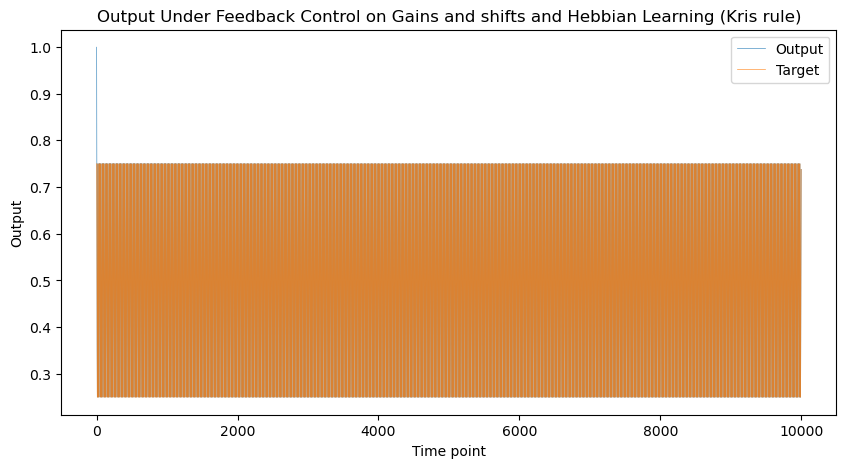

In [10]:
# define sigmoid
def sigmoid_np(x):
    return 1 / (1 + np.exp(-x))

def inv_sigmoid_np(x):
    return -np.log((1 / x) - 1)


# imitate rnn_FORCE
class mysys():
    def __init__(self, weight_matrix, connectivity_matrix, gain, shift, input_weight_matrix=None, inputs=None):
        # core parameters
        self.weight_matrix = weight_matrix
        self.connectivity_matrix = connectivity_matrix
        self.gain = gain
        self.shift = shift
        self.inputs = inputs
        self.input_weight_matrix = input_weight_matrix
        self.activation_func = nn.Sigmoid()
        
        # transfer into tensor
        self.weight_matrix_tensor = tensor(self.weight_matrix)
        self.gain_tensor = tensor(self.gain)
        self.shift_tensor = tensor(self.shift)
        
        # constants
        self.time_const = 1
        self.timestep = 0.1
        self.c = self.timestep / self.time_const
        self.g = 1.5

    def f_tensor(self, x_tensor, ug_tensor, us_tensor, r_tensor):
        # this_input_tensor = torch.matmul(tensor(self.input_weight_matrix), tensor([[self.inputs[self.i]]]))
        y_tensor = (1 - self.c) * x_tensor \
            + self.c * self.activation_func((self.gain_tensor + ug_tensor) * (self.g * torch.matmul(self.weight_matrix_tensor, x_tensor) + r_tensor - (self.shift_tensor + us_tensor)))
        return y_tensor
     
    def f(self, x, ug, us, r):
        x_tensor = tensor(x)
        ug_tensor = tensor(ug)
        us_tensor = tensor(us)
        r_tensor = tensor(r)
        y_tensor = self.f_tensor(x_tensor, ug_tensor, us_tensor, r_tensor)
        y = y_tensor.numpy()
        return y
    
    def jacob(self, x, ug, us, r):
        x_tensor = tensor(x)
        ug_tensor = tensor(ug)
        us_tensor = tensor(us)
        r_tensor = tensor(r)
        dydx, dydug, dydus, dydr = jacobian(self.f_tensor,(x_tensor, ug_tensor, us_tensor, r_tensor))
        Jx_tensor = dydx.squeeze(dim=(1,3))
        Jug_tensor = dydug.squeeze(dim=(1,3))
        Jus_tensor = dydus.squeeze(dim=(1,3))
        Jr_tensor = dydr.squeeze(dim=(1,3))
        Jx = Jx_tensor.numpy()
        Jug = Jug_tensor.numpy()
        Jus = Jus_tensor.numpy()
        Jr = Jr_tensor.numpy()
        return Jx, Jug, Jus, Jr

jnn = mysys(weight_matrix, connectivity_matrix, init_gain, init_shift)


#### FEEDBACK CONTROL AND HEBBIAN LEARNING WITH KRIS RULE ####

# Simulate with control
x = sigmoid_np(init_gain * (init_state.copy() - init_shift))
ug = init_state.copy() * 0
us = init_state.copy() * 0
this_output_weight_matrix = output_weight_matrix.copy()
xs_hebb, ugs_hebb, uss_hebb, outputs_hebb_beforesig, outputs_hebb = [x], [], [], [], []
has_hebbian = False
output_weights = [this_output_weight_matrix.copy()]

# constants
R = np.eye(2 * num_nodes) * 0.0001
Q1 = np.eye(num_nodes) * 0.001
Q2 = np.eye(1) * 10
pos_hebbian_lr = 0.05 #old parameters A+ = 0.05
neg_hebbian_lr = 0.07 #old parameters A- = 0.05
beta = 0.25 #old parameter 0.5
gainout= 2.5 
shiftout= -2.5 
period = 2 * half_period

for t in tqdm(time_points[:-1]):

    # output
    output_beforesig = this_output_weight_matrix @ x
    output = sigmoid_np(gainout * (output_beforesig - shiftout))

    # update readout weights by hebbian learning
    if not has_hebbian and t > 1000:
        has_hebbian = True
        x_mean = np.concatenate(xs_hebb, axis=1).mean(axis=1).reshape(-1, 1)
        x_std = np.concatenate(xs_hebb, axis=1).std(axis=1).reshape(-1, 1)
        # output_mean = np.array(outputs_fb).mean()
        output_mean = 0.5
    if has_hebbian:
        # Calculate Hebbian weight updates, only for ext nodes
        hebbian_update = ((output - output_mean) * ((x - x_mean) / x_std).T)[:, node_type == 1]
        ext_output_weight_matrix = this_output_weight_matrix[:, node_type == 1]
        f_plus = np.power(1 - ext_output_weight_matrix/ext_weight_sum, beta)
        f_minus = np.power(ext_output_weight_matrix/ext_weight_sum, beta)
        plus_index = hebbian_update > 0
        minus_index = hebbian_update < 0
        pos_hebbian_lr = 0 if output < output_mean else 0.05  # no LTP when output and x both below mean
        hebbian_update[plus_index] *= pos_hebbian_lr * f_plus[plus_index]
        hebbian_update[minus_index] *= neg_hebbian_lr * f_minus[minus_index]
        # Normalized Hebbian learning
        ext_output_weight_matrix = ext_output_weight_matrix + hebbian_update
        ext_output_weight_matrix[ext_output_weight_matrix < 0] = 0
        ext_output_weight_matrix /= np.sum(np.abs(ext_output_weight_matrix)) / ext_weight_sum
        # update init weights
        this_output_weight_matrix[:, node_type == 1] = ext_output_weight_matrix

    # input
    this_input = inputs[:,t]
    r = feedback_weight_matrix * this_input.reshape(-1,1)

    # linear approxmation of nonlinear system
    # linear approximate F and G
    F, Gg, Gs, _ = jnn.jacob(x, ug, us, r)   # x_t, u_t-1
    c = jnn.f(x, ug, us, r) - F @ x - Gg @ ug - Gs @ us # the constant term after approximation
    # augment the system for the constant term
    F_aug = np.concatenate([np.concatenate([F, np.eye(num_nodes)], axis=1), np.concatenate([np.zeros((num_nodes, num_nodes)), np.eye(num_nodes)], axis=1)], axis=0)
    G = np.concatenate([Gg, Gs], axis=1)  # num_nodes x 2*num_nodes
    G_aug = np.concatenate([G, np.zeros((num_nodes, 2 * num_nodes))], axis=0)
    x_aug = np.concatenate([x, c], axis=0)

    # get H
    H = this_output_weight_matrix.T
    L = H @ np.linalg.inv(H.T @ H)
    H_bar = (np.eye(num_nodes) - L @ H.T).T
    Q = H_bar @ Q1 @ H_bar.T + H @ Q2 @ H.T
    y_tilde = inv_sigmoid_np(targets[t+1]) / gainout + shiftout
    x_tilde = L @ np.array([[y_tilde]])
    x_tilde_aug = np.concatenate([x_tilde, c], axis=0)
    # Q_aug = np.concatenate([np.concatenate([Q, np.zeros((num_nodes, num_nodes))], axis=1), np.concatenate([np.zeros((num_nodes, num_nodes)), np.eye(num_nodes)], axis=1)], axis=0)
    Q_aug = np.concatenate([np.concatenate([Q, np.zeros((num_nodes, num_nodes))], axis=1), np.concatenate([np.zeros((num_nodes, num_nodes)), np.zeros((num_nodes, num_nodes))], axis=1)], axis=0)

    # get the control input u
    # backward solve
    S_t2 = Q_aug
    b_t2 = np.zeros(shape=(2 * num_nodes, 1))
    S_t1 = F_aug.T @ (S_t2 - S_t2 @ G_aug @ np.linalg.inv(G_aug.T @ S_t2 @ G_aug + R) @ G_aug.T @ S_t2) @ F_aug + Q_aug
    K_T_t1 = -np.linalg.inv(G_aug.T @ S_t2 @ G_aug + R) @ G_aug.T @ S_t2 @ F_aug
    b_t1 = (F_aug.T + K_T_t1.T @ G_aug.T) @ b_t2 - Q_aug @ x_tilde_aug
    # calculate u_t
    u1 = -np.linalg.inv(G_aug.T @ S_t1 @ G_aug + R) @ G_aug.T @ (S_t1 @ F_aug @ x_aug + b_t1)
    # update u
    u = u1.copy()
    
    # update x
    ug = u[0:num_nodes]
    us = u[num_nodes:]
    x1 = jnn.f(x, ug, us, r)
    x = x1.copy()
   
    # save
    xs_hebb.append(x)
    ugs_hebb.append(ug)
    uss_hebb.append(us)
    outputs_hebb_beforesig.append(output_beforesig.item())
    outputs_hebb.append(output.item())
    output_weights.append(this_output_weight_matrix.copy())

# final readout for x_T
output_beforesig = this_output_weight_matrix @ x
output = sigmoid_np(gainout * (output_beforesig - shiftout))
outputs_hebb_beforesig.append(output_beforesig.item())
outputs_hebb.append(output.item())



fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(time_points, outputs_hebb, label='Output', alpha=0.8, lw=0.5)
plt.plot(time_points, targets, label='Target', alpha=0.8, lw=0.5)
plt.title('Output Under Feedback Control on Gains and shifts and Hebbian Learning (Kris rule)')
plt.xlabel('Time point')
plt.ylabel('Output')
plt.legend()

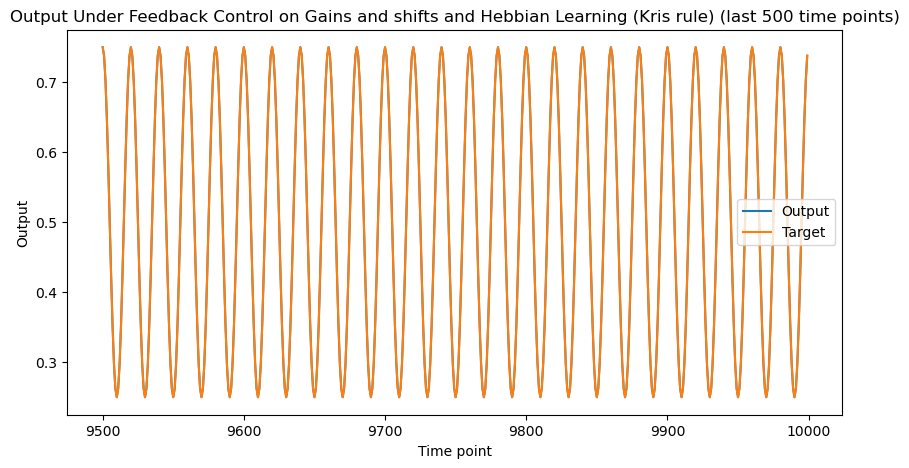

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(time_points[-500:], outputs_hebb[-500:], label='Output')
plt.plot(time_points[-500:], targets[-500:], label='Target')
plt.title('Output Under Feedback Control on Gains and shifts and Hebbian Learning (Kris rule) (last 500 time points)')
plt.xlabel('Time point')
plt.ylabel('Output')
plt.legend()

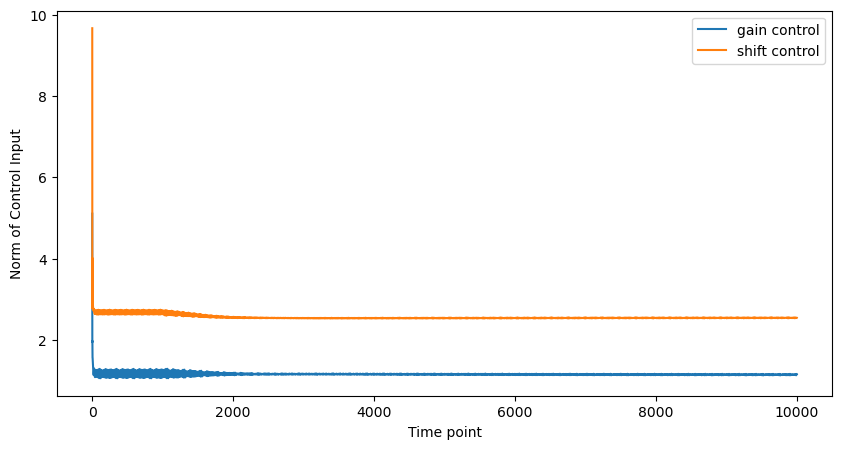

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ugs_norm = [np.linalg.norm(u) for u in ugs_hebb]
uss_norm = [np.linalg.norm(u) for u in uss_hebb]

plt.plot(ugs_norm, label='gain control')
plt.plot(uss_norm, label = 'shift control')
plt.ylabel('Norm of Control Input')
plt.xlabel('Time point')
plt.legend()

Text(0.5, 1.0, 'Readout weight matrix before and after hebbian learning')

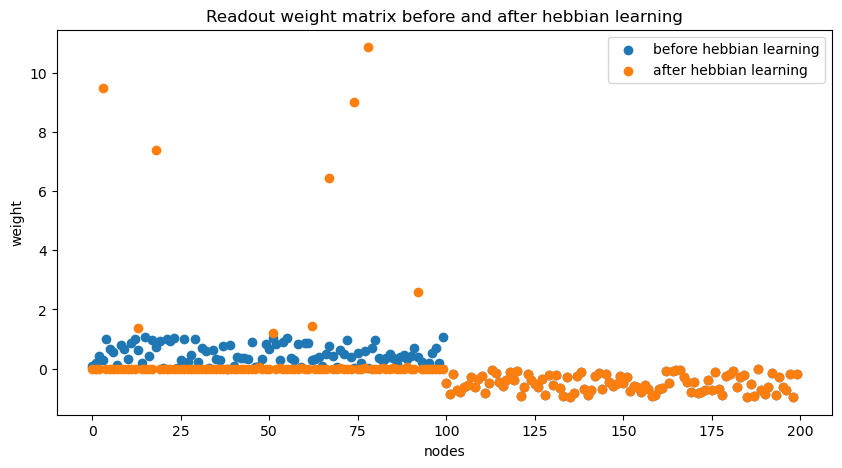

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
plt.scatter(np.arange(num_nodes), output_weight_matrix.reshape(-1,1), label='before hebbian learning')
plt.scatter(np.arange(num_nodes), this_output_weight_matrix.reshape(-1,1), label='after hebbian learning')
plt.xlabel('nodes')
plt.ylabel('weight')
plt.legend()
plt.title("Readout weight matrix before and after hebbian learning")

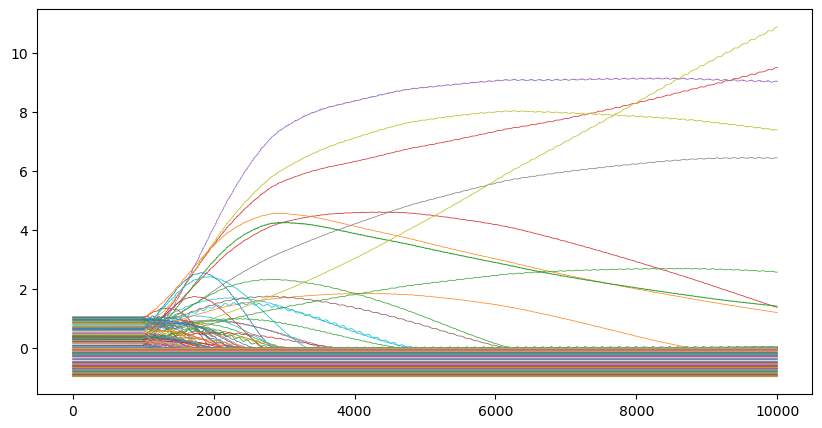

In [16]:
plt.subplots(figsize=(10, 5))
all_output_weights = np.concatenate(output_weights, axis=0).T
for i in range(num_nodes):
    plt.plot(all_output_weights[i,:], label=f"Node {i}", lw=0.5)

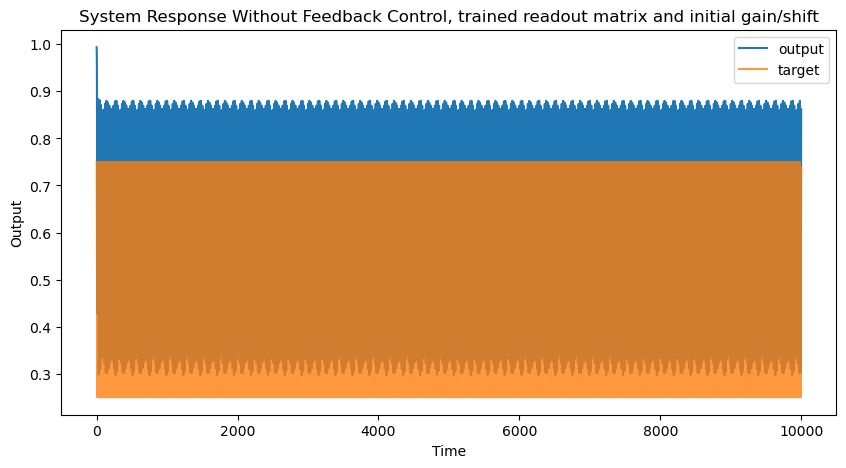

Text(0.5, 1.0, 'System Response Without Feedback Control, initial gain/shift (first 500 time points)')

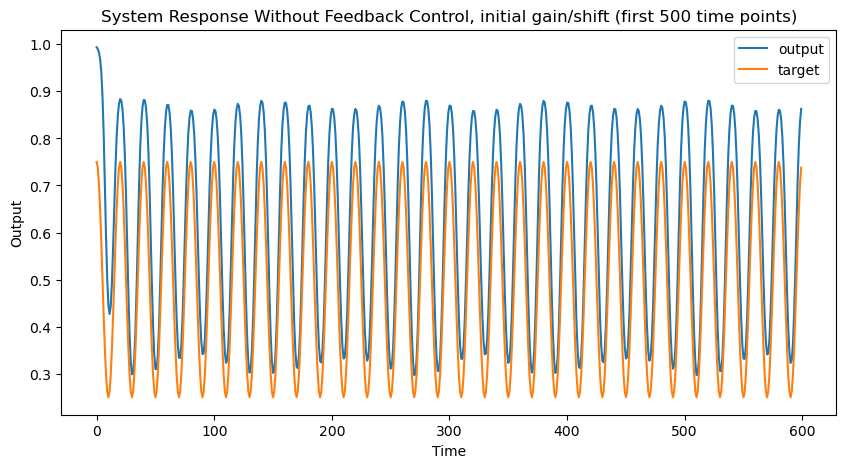

In [14]:
jnn_ff = mysys(weight_matrix, connectivity_matrix, init_gain, init_shift)

# Simulation Without Control
x = sigmoid_np(init_gain * (init_state.copy() - init_shift))
ug = init_state.copy() * 0
us = init_state.copy() * 0
xs_ff_after, outputs_ff_after = [x], []
gainout = 2.5 # 1
shiftout =-2 # -1.6

for i in time_points[:-1]:

    # output
    output_beforesig = this_output_weight_matrix @ x
    output = sigmoid_np(gainout * (output_beforesig - shiftout))

    # input
    this_input = inputs[:,i]
    r = feedback_weight_matrix * this_input.reshape(-1, 1)
    
    # update x
    x1 = jnn_ff.f(x, ug, us, r)
    x = x1.copy()

    # save
    xs_ff_after.append(x)
    outputs_ff_after.append(output.item())

# final readout for x_T
output_beforesig = this_output_weight_matrix @ x
output = sigmoid_np(gainout * (output_beforesig - shiftout))
outputs_ff_after.append(output.item())

# Plot the output
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(time_points, outputs_ff_after,label='output')
plt.plot(time_points, targets,label='target',alpha=0.8 )
plt.xlabel('Time')
plt.legend()
plt.ylabel('Output')
plt.title('System Response Without Feedback Control, trained readout matrix and initial gain/shift')
plt.show()

# Plot the output
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(time_points[0:600], outputs_ff_after[0:600], label='output')
plt.plot(time_points[0:600], targets[0:600], label='target')
plt.xlabel('Time')
plt.ylabel('Output')
plt.legend()
plt.title('System Response Without Feedback Control, initial gain/shift (first 500 time points)')

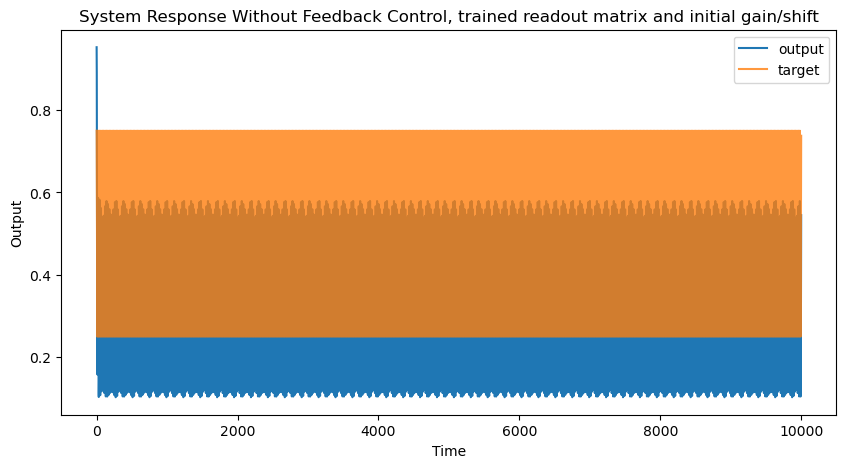

Text(0.5, 1.0, 'System Response Without Feedback Control, initial gain/shift (first 500 time points)')

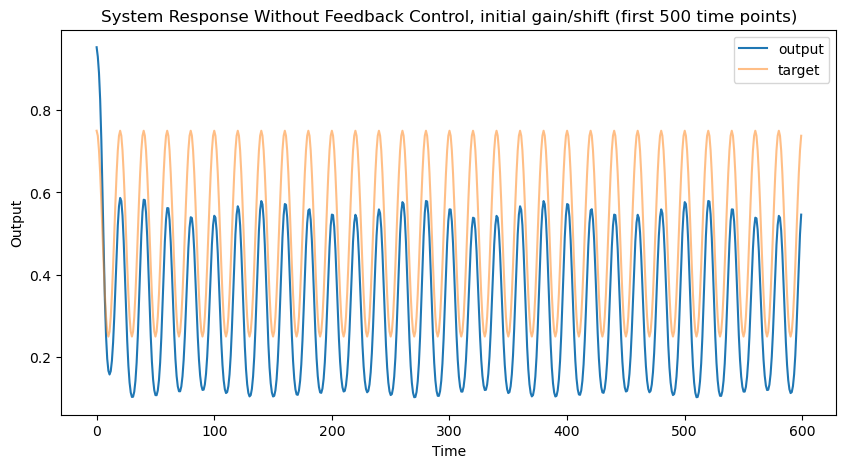

In [15]:
jnn_ff = mysys(weight_matrix, connectivity_matrix, init_gain, init_shift)

# Simulation Without Control
x = sigmoid_np(init_gain * (init_state.copy() - init_shift))
ug = init_state.copy() * 0
us = init_state.copy() * 0
xs_ff_after, outputs_ff_after = [x], []
gainout = 2.18 #2.5 # 1
shiftout =-1.35 #-2 # -1.6

for i in time_points[:-1]:

    # output
    output_beforesig = this_output_weight_matrix @ x
    output = sigmoid_np(gainout * (output_beforesig - shiftout))

    # input
    this_input = inputs[:,i]
    r = feedback_weight_matrix * this_input.reshape(-1, 1)
    
    # update x
    x1 = jnn_ff.f(x, ug, us, r)
    x = x1.copy()

    # save
    xs_ff_after.append(x)
    outputs_ff_after.append(output.item())

# final readout for x_T
output_beforesig = this_output_weight_matrix @ x
output = sigmoid_np(gainout * (output_beforesig - shiftout))
outputs_ff_after.append(output.item())

# Plot the output
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(time_points, outputs_ff_after,label='output')
plt.plot(time_points, targets,label='target',alpha=0.8 )
plt.xlabel('Time')
plt.legend()
plt.ylabel('Output')
plt.title('System Response Without Feedback Control, trained readout matrix and initial gain/shift')
plt.show()

# Plot the output
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(time_points[0:600], outputs_ff_after[0:600], label='output')
plt.plot(time_points[0:600], targets[0:600], label='target', alpha=0.5)
plt.xlabel('Time')
plt.ylabel('Output')
plt.legend()
plt.title('System Response Without Feedback Control, initial gain/shift (first 500 time points)')